In [1]:
from pyspark.sql import SparkSession

# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("MAST30034 Tutorial 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/02 18:45:36 WARN Utils: Your hostname, Dinadis-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.143 instead (on interface en0)
26/10/02 18:45:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/02 18:45:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Reading in the SA2 spatial boundary data
from urllib.request import urlretrieve
import os
import zipfile
import geopandas as gpd
from glob import glob

# ABS SA2 boundary file (2021, GDA2020)
ABS_SPATIAL_FILES = {
    "SA2_2021_AUST_SHP_GDA2020.zip":
    "https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs/edition-3-july-2021-june-2026/access-and-downloads/digital-boundary-files/SA2_2021_AUST_SHP_GDA2020.zip"
}

# Output directory
output_relative_dir = '../data/'
spatial_output_dir = output_relative_dir + 'raw_abs'
os.makedirs(spatial_output_dir, exist_ok=True)

# Download
for filename, url in ABS_SPATIAL_FILES.items():
    output_path = os.path.join(spatial_output_dir, filename)

    if os.path.exists(output_path):
        print(f"Already downloaded: {filename}")
        continue

    print(f"Downloading {filename}...")
    urlretrieve(url, output_path)
    print(f"Completed {filename}")

# Extract
for filename in ABS_SPATIAL_FILES:
    zip_path = os.path.join(spatial_output_dir, filename)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(spatial_output_dir)

    print(f"Extracted: {filename}")

# Find the extracted shapefile
shapefiles = glob(os.path.join(spatial_output_dir, "*.shp"))
sa2_shapefile = next(
    path for path in shapefiles
    if os.path.basename(path).startswith("SA2_2021")
)

# Read the boundaries
sa2_boundaries = gpd.read_file(sa2_shapefile)

print(sa2_boundaries.shape)
print(sa2_boundaries.columns.tolist())
sa2_boundaries.head()

Already downloaded: SA2_2021_AUST_SHP_GDA2020.zip
Extracted: SA2_2021_AUST_SHP_GDA2020.zip
(2473, 17)
['SA2_CODE21', 'SA2_NAME21', 'CHG_FLAG21', 'CHG_LBL21', 'SA3_CODE21', 'SA3_NAME21', 'SA4_CODE21', 'SA4_NAME21', 'GCC_CODE21', 'GCC_NAME21', 'STE_CODE21', 'STE_NAME21', 'AUS_CODE21', 'AUS_NAME21', 'AREASQKM21', 'LOCI_URI21', 'geometry']


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.218 -35.366..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.1997 -35.35..."


In [3]:
sa2_boundaries = gpd.read_file(os.path.join(spatial_output_dir, "SA2_2021_AUST_GDA2020.shp"))

print("Shape:", sa2_boundaries.shape)
print("Columns:", sa2_boundaries.columns.tolist())

print(sa2_boundaries.head())
print(sa2_boundaries.info())

Shape: (2473, 17)
Columns: ['SA2_CODE21', 'SA2_NAME21', 'CHG_FLAG21', 'CHG_LBL21', 'SA3_CODE21', 'SA3_NAME21', 'SA4_CODE21', 'SA4_NAME21', 'GCC_CODE21', 'GCC_NAME21', 'STE_CODE21', 'STE_NAME21', 'AUS_CODE21', 'AUS_NAME21', 'AREASQKM21', 'LOCI_URI21', 'geometry']
  SA2_CODE21                       SA2_NAME21 CHG_FLAG21  CHG_LBL21  \
0  101021007                        Braidwood          0  No change   
1  101021008                          Karabar          0  No change   
2  101021009                       Queanbeyan          0  No change   
3  101021010                Queanbeyan - East          0  No change   
4  101021012  Queanbeyan West - Jerrabomberra          0  No change   

  SA3_CODE21  SA3_NAME21 SA4_CODE21      SA4_NAME21 GCC_CODE21   GCC_NAME21  \
0      10102  Queanbeyan        101  Capital Region      1RNSW  Rest of NSW   
1      10102  Queanbeyan        101  Capital Region      1RNSW  Rest of NSW   
2      10102  Queanbeyan        101  Capital Region      1RNSW  Rest of N

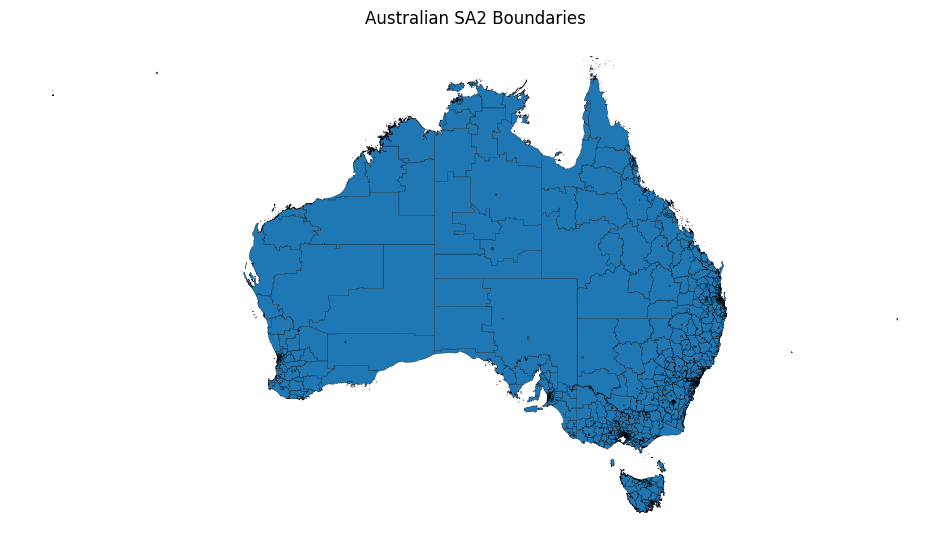

In [4]:
# Checking to see if the SA2 boundary data was properly read in 
import matplotlib.pyplot as plt

sa2_boundaries.plot(
    figsize=(12, 10),
    edgecolor="black",
    linewidth=0.2
)

plt.title("Australian SA2 Boundaries")
plt.axis("off")
plt.show()

In [5]:
import pandas as pd
CURATED_DIR = "../data/curated/curated_transactions/part_2.parquet"

# Load the ETL curated transaction level dataset 
curated_df = pd.read_parquet(CURATED_DIR)
print(curated_df.columns.tolist())
print(curated_df.info())

['user_id', 'merchant_abn', 'dollar_value', 'order_id', 'order_datetime', 'name_consumer', 'address', 'state', 'postcode', 'gender', 'consumer_id', 'name_merchant', 'tags', 'consumer_fraud_probability', 'merchant_fraud_probability', 'consumer_is_fraud', 'merchant_is_fraud', 'POA_CODE_2021', 'SA2_CODE_2021', 'mb_count', 'poa_total', 'ratio', 'SA2_NAME_2021', 'disadvantage_score', 'disadvantage_decile', 'adv_disadv_score', 'adv_disadv_decile', 'economic_resources_score', 'economic_resources_decile', 'education_occupation_score', 'education_occupation_decile', 'usual_resident_population']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3643266 entries, 0 to 3643265
Data columns (total 32 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   user_id                      int64         
 1   merchant_abn                 int64         
 2   dollar_value                 float64       
 3   order_id                     object        


In [6]:
# Checking for missing values in SA2 in the curated df
SA2_COL = "SA2_CODE_2021" 

print("Missing SA2:", curated_df[SA2_COL].isna().sum())
print("Total rows:", len(curated_df))
print(
    "Missing SA2 percentage:",
    round(curated_df[SA2_COL].isna().mean() * 100, 2),
    "%" \
    ""
)

Missing SA2: 600030
Total rows: 3643266
Missing SA2 percentage: 16.47 %


In [7]:
BOUNDARY_SA2_COL = "SA2_CODE21"  # Replace with actual column name

# Validating the data types of the SA2 columns of both datasets as explicit strings 
curated_df[SA2_COL] = curated_df[SA2_COL].astype("string").str.strip()
sa2_boundaries[BOUNDARY_SA2_COL] = sa2_boundaries[BOUNDARY_SA2_COL].astype("string").str.strip()

# Checking the unique SA2 regions in the ABS dataset and the unique SA2 regions in the transaction dataset
print("Unique transaction SA2s:", curated_df[SA2_COL].nunique())
print("Unique boundary SA2s:", sa2_boundaries[BOUNDARY_SA2_COL].nunique())


Unique transaction SA2s: 1491
Unique boundary SA2s: 2473


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2473 entries, 0 to 2472
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   SA2_CODE21                 2473 non-null   string  
 1   SA2_NAME21                 2473 non-null   object  
 2   CHG_FLAG21                 2473 non-null   object  
 3   CHG_LBL21                  2473 non-null   object  
 4   SA3_CODE21                 2473 non-null   object  
 5   SA3_NAME21                 2473 non-null   object  
 6   SA4_CODE21                 2473 non-null   object  
 7   SA4_NAME21                 2473 non-null   object  
 8   GCC_CODE21                 2473 non-null   object  
 9   GCC_NAME21                 2473 non-null   object  
 10  STE_CODE21                 2473 non-null   object  
 11  STE_NAME21                 2473 non-null   object  
 12  AUS_CODE21                 2473 non-null   object  
 13  AUS_NAME21               

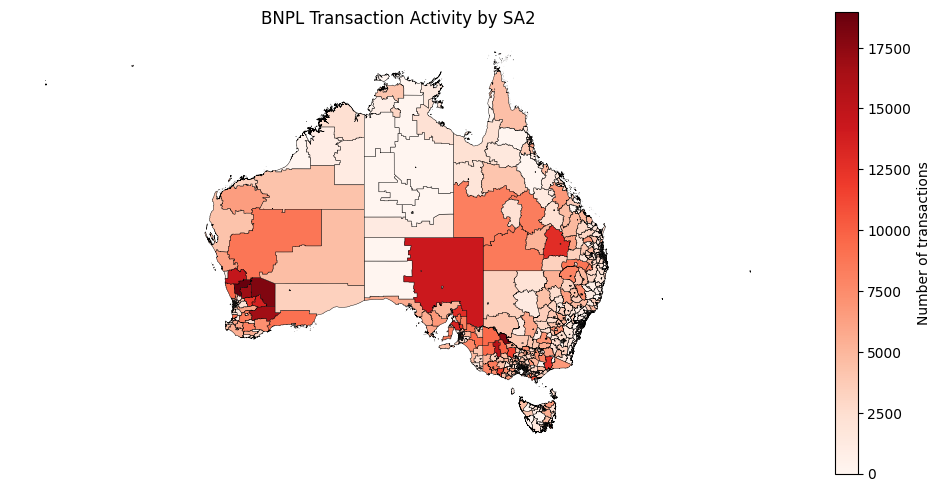

,SA2 Code,SA2 Region Name,State,Transaction Count,Total Spend ($)
0,509021241,Moora,Western Australia,18986.0,3.162642e+06
1,509021242,Mukinbudin,Western Australia,18020.0,3.127553e+06
2,215031405,Swan Hill Surrounds,Victoria,17768.0,2.911858e+06
3,509021238,Dowerin,Western Australia,16896.0,2.774429e+06
4,509031247,Kulin,Western Australia,16714.0,2.891559e+06


In [8]:
# Aggregating the transaction level data into a SA2 region level dataset
sa2_level = (
    curated_df.dropna(subset=[SA2_COL])
    .groupby(SA2_COL)
    .agg(
        transaction_count=("order_id", "count"),
        total_spend=("dollar_value", "sum"),
        average_transaction_value=("dollar_value", "mean"),
        unique_consumers=("consumer_id", "nunique")
    )
    .reset_index()
)

sa2_level.head()

# Merging the SA2 level dataset with the SA2 boundaries data on the SA2 region index  
geo_data = sa2_boundaries.merge(
    sa2_level,
    left_on=BOUNDARY_SA2_COL,
    right_on=SA2_COL,
    how="left"
)

geo_data["transaction_count"] = (
    geo_data["transaction_count"].fillna(0)
)

print(geo_data.info())
print(geo_data.shape)
print(geo_data[["transaction_count", "total_spend"]].describe())


# Producing the geo spatial chlorpleth for transaction activity by SA2 regions 
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

geo_data.plot(
    column="transaction_count",
    cmap="Reds",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Number of transactions",
        "shrink": 0.6
    }
)

ax.set_title("BNPL Transaction Activity by SA2")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Extract and Display Top 5 SA2 Regions
top_5_regions = (
    geo_data
    .nlargest(5, "transaction_count")
    [["SA2_CODE21", "SA2_NAME21", "STE_NAME21", "transaction_count", "total_spend"]]
    .reset_index(drop=True)
)

# Rename columns for presentation
top_5_regions.columns = ["SA2 Code", "SA2 Region Name", "State", "Transaction Count", "Total Spend ($)"]

top_5_regions

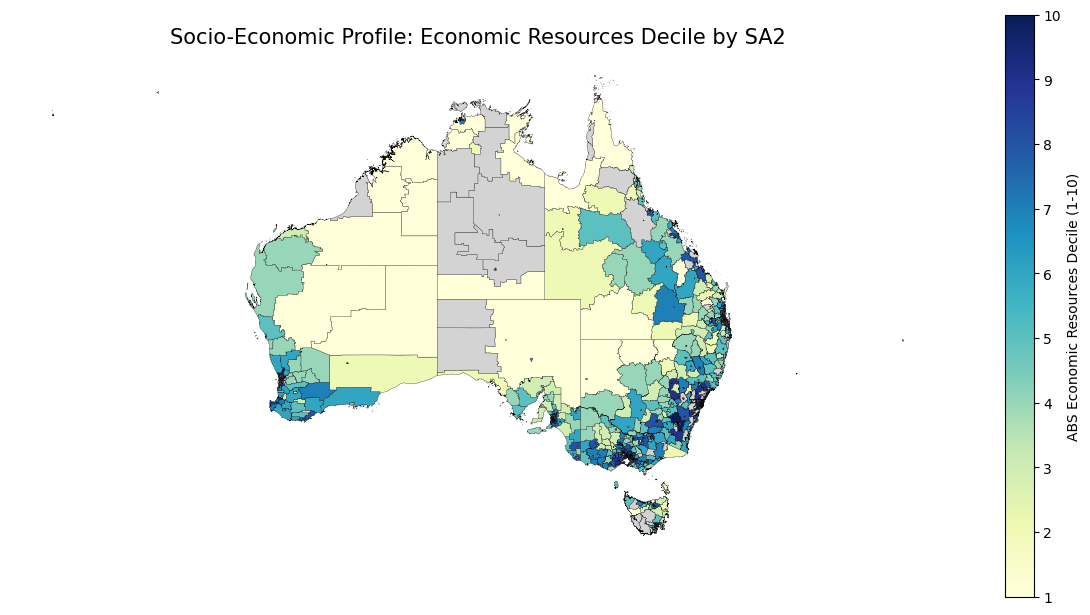

In [9]:
# Aggregate socio-economic attributes from curated_df per SA2 region 
sa2_seifa_summary = (
    curated_df
    .dropna(subset=[SA2_COL])
    .groupby(SA2_COL)
    .agg(
        # SEIFA Socio-Economic Metrics (taking .first() they are uniform per SA2 and thererfore identical)
        disadvantage_score=("disadvantage_score", "first"),
        disadvantage_decile=("disadvantage_decile", "first"),
        economic_resources_score=("economic_resources_score", "first"),
        economic_resources_decile=("economic_resources_decile", "first"),
        adv_disadv_score=("adv_disadv_score", "first"),
        education_occupation_score=("education_occupation_score", "first"),
        population=("usual_resident_population", "first"),
        
        # Transaction activity for context
        transaction_count=("order_id", "count"),
        total_spend=("dollar_value", "sum")
    )
    .reset_index()
)

sa2_seifa_summary[SA2_COL] = (sa2_seifa_summary[SA2_COL].astype("string").str.strip())
sa2_boundaries[BOUNDARY_SA2_COL] = (sa2_boundaries[BOUNDARY_SA2_COL].astype("string").str.strip())

# Merge back with spatial polygons
geo_seifa = sa2_boundaries.merge(
    sa2_seifa_summary,
    left_on=BOUNDARY_SA2_COL,
    right_on=SA2_COL,
    how="left"
)


# Plotting 
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

geo_seifa.plot(
    column="economic_resources_decile",
    cmap="YlGnBu",              # Yellow to Green to Blue gradient
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data / Unmatched"
    },
    legend_kwds={
        "label": "ABS Economic Resources Decile (1-10)",
        "shrink": 0.6
    }
)

ax.set_title("Socio-Economic Profile: Economic Resources Decile by SA2", fontsize=15)
ax.axis("off")
plt.tight_layout()
plt.show()


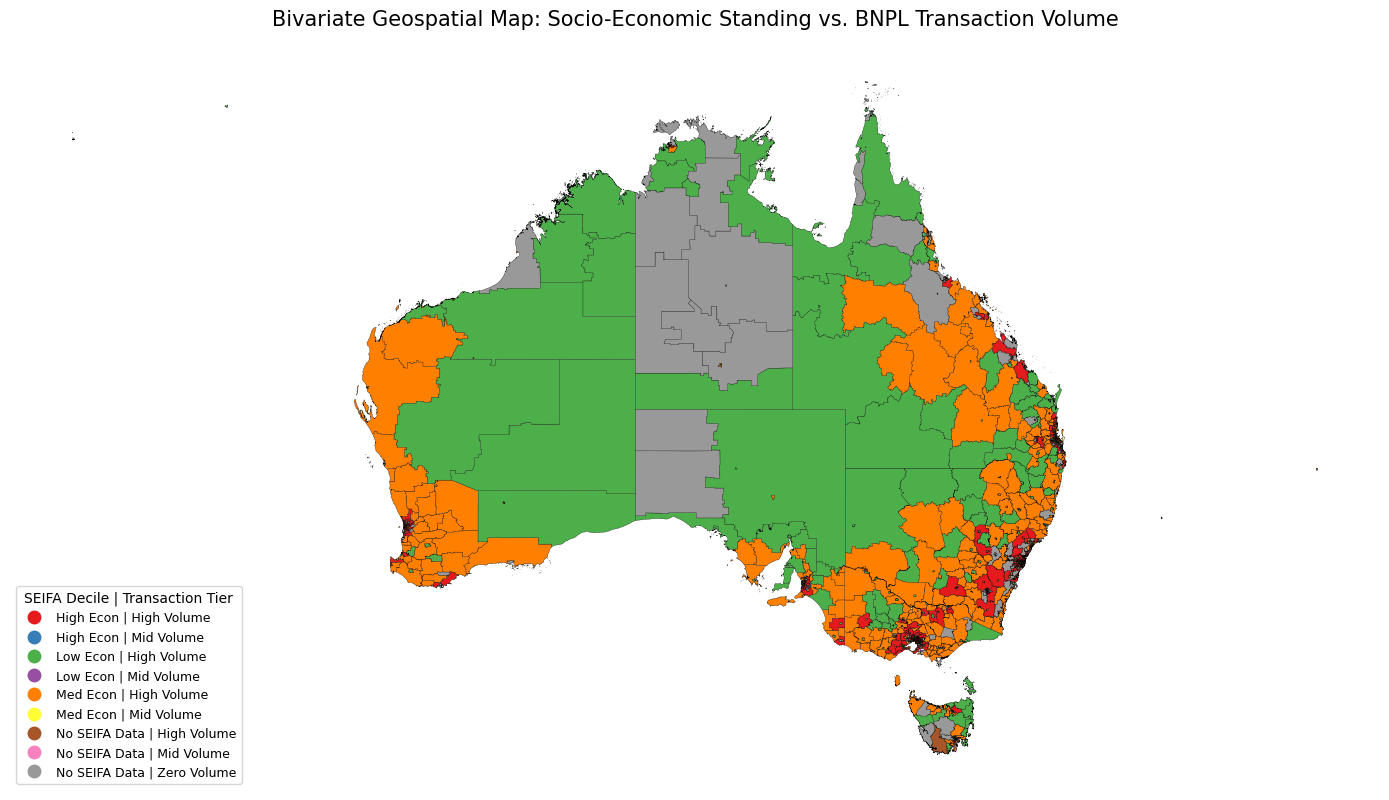

,SA2_CODE21,SA2_NAME21,STE_NAME21,economic_resources_decile,transaction_count
308,115011558,Cherrybrook,New South Wales,10.0,135.0
402,119011658,Panania (South) - Picnic Point,New South Wales,8.0,451.0
502,123011701,Mount Annan,New South Wales,10.0,427.0
600,127011727,Gledswood Hills - Gregory Hills,New South Wales,10.0,454.0
811,207011149,Camberwell,Victoria,9.0,476.0
976,211051281,Mooroolbark,Victoria,8.0,445.0
1049,213011340,Taylors Lakes,Victoria,9.0,455.0
1407,309031239,Paradise Point - Hollywell,Queensland,8.0,324.0
1723,401021008,Mount Barker Surrounds,South Australia,9.0,298.0
1740,402011025,Gawler - North,South Australia,8.0,329.0


In [10]:
# Geo spatial chlorpleth for Economic Decile and Transaction Volumes combined

# Creating SEIFA Economic Deciles and Transaction Volume levels 
# Categorize Economic Deciles (1-3: Low, 4-7: Med, 8-10: High)
geo_seifa["econ_level"] = pd.cut(
    geo_seifa["economic_resources_decile"],
    bins=[0, 3, 7, 10],
    labels=["Low Econ", "Med Econ", "High Econ"],
    include_lowest=True
)

# Update SA2 regions with no transaction data as 0 for transaction volume explicitly
max_vol = geo_seifa["transaction_count"].fillna(0).max()

# Categorize Transaction Volume levels (0: Zero Volume, 0-500: Mid Volume, 500+: High Volume) 
geo_seifa["vol_level"] = pd.cut(
    geo_seifa["transaction_count"].fillna(0),
    bins=[-1, 0, 500, max_vol + 1],
    labels=["Zero Volume", "Mid Volume", "High Volume"], 
    include_lowest=True
)

# Combine the economical decile and transaction volume levels into single categorical bivariate label
econ_str = geo_seifa["econ_level"].astype(str).replace("nan", "No SEIFA Data")
vol_str = geo_seifa["vol_level"].astype(str)

geo_seifa["bivariate_class"] = econ_str + " | " + vol_str

# Plotting the Bivariate Geo Choropleth Map
fig, ax = plt.subplots(figsize=(14, 11))

geo_seifa.plot(
    column="bivariate_class",
    cmap="Set1",
    categorical=True,
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No Data"}, # Misiing/unavailable SA2 data
    legend_kwds={
        "loc": "lower left",
        "title": "SEIFA Decile | Transaction Tier",
        "fontsize": 9,
        "title_fontsize": 10
    }
)

ax.set_title(
    "Bivariate Geospatial Map: Socio-Economic Standing vs. BNPL Transaction Volume",
    fontsize=15,
    pad=15
)
ax.axis("off")

plt.tight_layout()
plt.show()


# Identifying regions with High Wealth (High Econ) but currently Zero or Low Volume
notable_regions = geo_seifa[
    (geo_seifa["econ_level"] == "High Econ") & 
    (geo_seifa["vol_level"].isin(["Zero Volume", "Mid Volume"]))
][["SA2_CODE21", "SA2_NAME21", "STE_NAME21", "economic_resources_decile", "transaction_count"]]

notable_regions.head(10)